# 08 — Refined axes validity

Build atomic constructs and test coverage / coherence **before** seeing outcomes.
Prefer components when composites disagree (same rule as Stage 10 NB05).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("08_refined_axes_validity")
cfg = ctx.cfg

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity


In [2]:
frame = nh.load_refined_frame(cfg, mode="strict")
manifest = pd.read_parquet(cfg.output_path("book_features_dir") / "refined_frame_manifest.parquet")
display(manifest.sort_values("nonzero_books", ascending=False).head(40))
ctx.save_table(manifest, "construct_coverage")

,column,nonzero_books,mean,median
8,RAX_emotional_reassurance,15994,0.0717,0.0681
41,RAX_h3_emotional_side,15994,0.0441,0.0413
37,RAX_h1_emotional_side,15994,0.0938,0.0913
9,RAX_emotional_security,15994,0.0360,0.0336
35,RAX_status_display,15993,0.0264,0.0252
18,RAX_individual_distress,15990,0.0265,0.0247
0,RAX_arc_falling,15987,0.0182,0.0167
1,RAX_arc_rising,15987,0.0444,0.0429
12,RAX_external_danger_crisis,15982,0.0119,0.0099
51,RAX_arc_rising_begin,15981,0.0388,0.0376


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/construct_coverage.csv  (60 rows)


## Atomic construct distributions (no outcome conditioning)

In [3]:
atoms = [
    c
    for c in frame.columns
    if c.startswith("RAX_")
    and not c.startswith("RAX_h")
    and "begin" not in c
    and "end" not in c
]
usable = frame[frame.get("analysable", True) == True] if "analysable" in frame.columns else frame
summary = pd.DataFrame(
    {
        "construct": atoms,
        "pct_nonzero": [(usable[c] > 0).mean() * 100 for c in atoms],
        "mean": [usable[c].mean() for c in atoms],
        "median": [usable[c].median() for c in atoms],
        "p90": [usable[c].quantile(0.9) for c in atoms],
    }
).sort_values("mean", ascending=False)
display(summary.round(4))
ctx.save_table(summary, "atomic_construct_summary")

,construct,pct_nonzero,mean,median,p90
8,RAX_emotional_reassurance,99.9687,0.0717,0.0681,0.0927
1,RAX_arc_rising,99.9250,0.0444,0.0429,0.0635
9,RAX_emotional_security,99.9687,0.0360,0.0336,0.0507
17,RAX_individual_distress,99.9437,0.0265,0.0247,0.0385
34,RAX_status_display,99.9625,0.0264,0.0252,0.0374
0,RAX_arc_falling,99.9250,0.0182,0.0167,0.0248
33,RAX_sexual_tension,99.8500,0.0156,0.0132,0.0270
22,RAX_nonexplicit_affection,99.3250,0.0152,0.0126,0.0312
12,RAX_external_danger_crisis,99.8937,0.0119,0.0099,0.0193
15,RAX_final_relational_payoff,99.7625,0.0096,0.0083,0.0169


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/atomic_construct_summary.csv  (35 rows)


## Inter-construct correlations

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/figures/construct_correlations.png


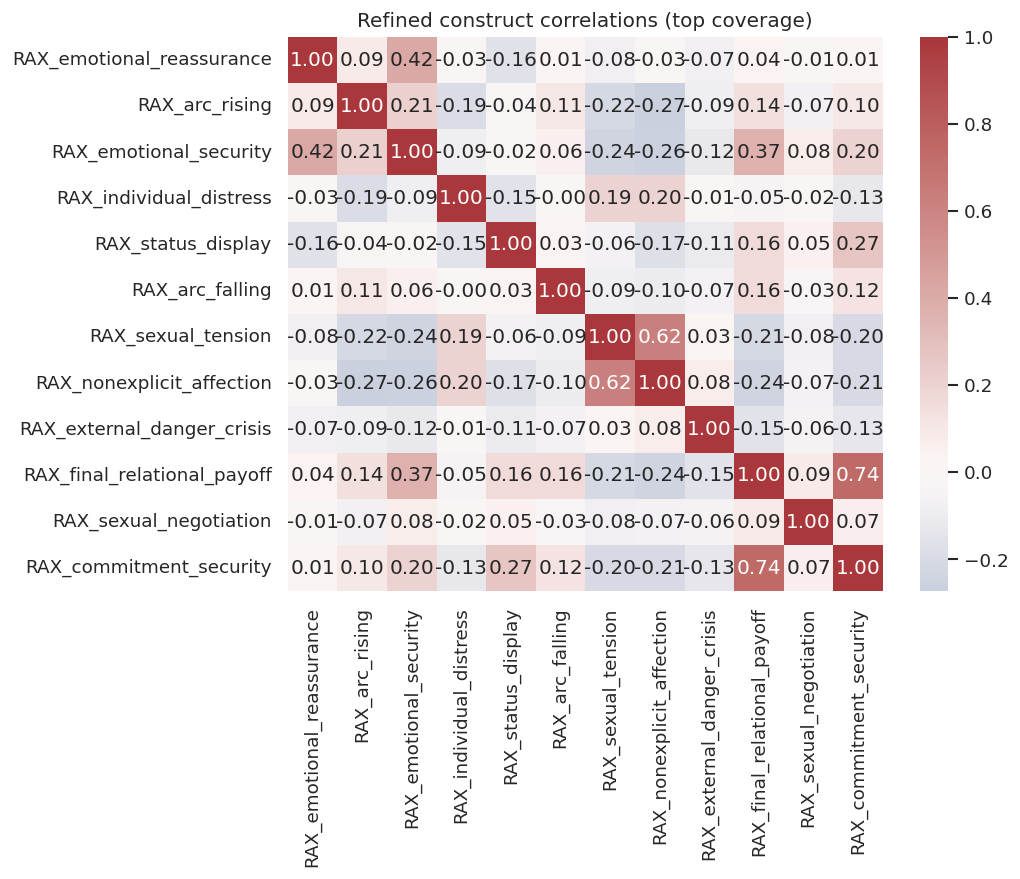

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/construct_correlations.csv  (12 rows)


In [4]:
top = summary.head(12)["construct"].tolist()
corr = usable[top].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Refined construct correlations (top coverage)")
ctx.save_figure(fig, "construct_correlations")
plt.show()
ctx.save_table(corr.reset_index(), "construct_correlations")

## Strict vs weighted agreement

In [5]:
strict = nh.load_refined_frame(cfg, "strict")
weighted = nh.load_refined_frame(cfg, "weighted")
common = [c for c in atoms if c in weighted.columns]
agree = []
for c in common:
    r = np.corrcoef(strict[c].fillna(0), weighted[c].fillna(0))[0, 1]
    agree.append({"construct": c, "corr_strict_weighted": float(r)})
agree_df = pd.DataFrame(agree).sort_values("corr_strict_weighted")
display(agree_df)
ctx.save_table(agree_df, "strict_vs_weighted_agreement")

/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,construct,corr_strict_weighted
12,RAX_external_danger_crisis,0.7639
17,RAX_individual_distress,0.7643
33,RAX_sexual_tension,0.9600
0,RAX_arc_falling,0.9618
9,RAX_emotional_security,0.9816
32,RAX_sexual_negotiation,0.9915
34,RAX_status_display,0.9926
1,RAX_arc_rising,0.9932
27,RAX_practical_care,0.9948
8,RAX_emotional_reassurance,0.9970


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/strict_vs_weighted_agreement.csv  (35 rows)


## Author concentration (top construct)

In [6]:
if "author_id" in usable.columns and top:
    c0 = top[0]
    by_auth = usable.groupby("author_id")[c0].mean().sort_values(ascending=False)
    print(f"Top construct {c0}: top author mean={by_auth.iloc[0]:.4f}, median author={by_auth.median():.4f}")
    print(f"Share of books from singleton authors: {(usable.groupby('author_id').size() == 1).mean():.1%}")

print("Validity checks complete — proceed to hypothesis tests in notebook 09.")

Top construct RAX_emotional_reassurance: top author mean=0.3575, median author=0.0684
Share of books from singleton authors: 64.8%
Validity checks complete — proceed to hypothesis tests in notebook 09.
